### 1. 데이터 로드 및 병합
기상청에서 다운로드한 3개의 파일을 하나로 합치고 기초적인 정보를 확인합니다.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 파일 리스트 정의
files = ['/workspaces/Daegun26Veritas/data/20503data1.csv', '/workspaces/Daegun26Veritas/data/20503data2.csv', '/workspaces/Daegun26Veritas/data/20503data3.csv']

# cp949 인코딩으로 데이터 로드 및 병합
data_list = [pd.read_csv(f, encoding='cp949') for f in files]
df = pd.concat(data_list, ignore_index=True)

print(f"전체 데이터 개수: {len(df)}개")
display(df.head())

전체 데이터 개수: 10956개


,지점,지점명,일시,평균기온(°C),최고기온(°C),평균 상대습도(%)
0,143,대구,1996-07-13,20.1,24.7,79.0
1,143,대구,1996-07-14,23.5,30.2,75.3
2,143,대구,1996-07-15,26.0,30.0,72.5
3,143,대구,1996-07-16,28.6,32.7,59.5
4,143,대구,1996-07-17,28.9,34.5,65.3


### 2. 데이터 전처리 및 피처 엔지니어링
결측치를 제거하고, 시계열 데이터의 핵심인 '내일의 기온' 컬럼을 생성합니다.

In [8]:
# '일시' 컬럼을 datetime 형식으로 변환
df['일시'] = pd.to_datetime(df['일시'])

# 실제 컬럼명에 맞춰 결측치 제거 (단위 및 공백 포함)
df = df.dropna(subset=['평균기온(°C)', '최고기온(°C)', '평균 상대습도(%)'])

# shift(-1)을 사용하여 다음날 최고기온을 타겟(y)으로 설정
df['내일_최고기온'] = df['최고기온(°C)'].shift(-1).copy()

# 마지막 행 결측치 처리
df = df.dropna(subset=['내일_최고기온'])

print("전처리 완료. 데이터 요약:")
display(df[['일시', '최고기온(°C)', '내일_최고기온']].head())

전처리 완료. 데이터 요약:


,일시,최고기온(°C),내일_최고기온
0,1996-07-13,24.7,30.2
1,1996-07-14,30.2,30.0
2,1996-07-15,30.0,32.7
3,1996-07-16,32.7,34.5
4,1996-07-17,34.5,34.8


### 3. 모델 학습 및 평가
학습 데이터와 테스트 데이터를 8:2 비율로 나누고 선형 회귀 모델을 학습시킵니다.

In [9]:
# 독립변수(X)와 종속변수(y) 설정 (정확한 컬럼명 사용)
X = df[['평균기온(°C)', '최고기온(°C)', '평균 상대습도(%)']]
y = df['내일_최고기온']

# 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 및 성능 평가
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse:.4f}")
print(f"모델 결정계수(R2 Score): {model.score(X_test, y_test):.4f}")

Mean Squared Error: 10.3859
모델 결정계수(R2 Score): 0.8885


### 4. 시각화
실제 값과 예측 값이 얼마나 일치하는지 산점도를 통해 확인합니다.

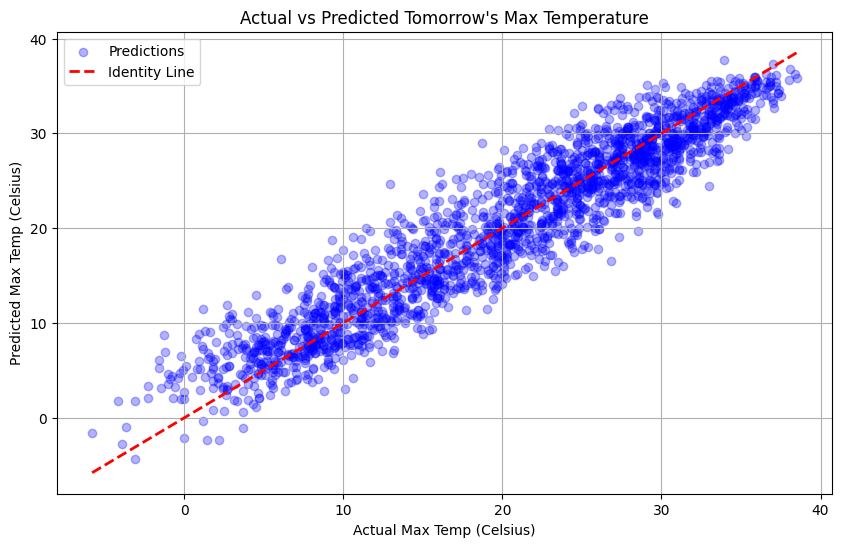

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.3, color='blue', label='Predictions')

# 기준 정답선 (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Identity Line')

plt.title('Actual vs Predicted Tomorrow\'s Max Temperature')
plt.xlabel('Actual Max Temp (Celsius)')
plt.ylabel('Predicted Max Temp (Celsius)')
plt.legend()
plt.grid(True)
plt.show()

### 🚀 통합 데이터 파이프라인 (Data Loading to Visualization)
위의 모든 과정을 하나의 프로세스로 통합한 코드입니다.

--- 모델 평가 결과 ---
Mean Squared Error: 10.3859
R2 Score (결정계수): 0.8885


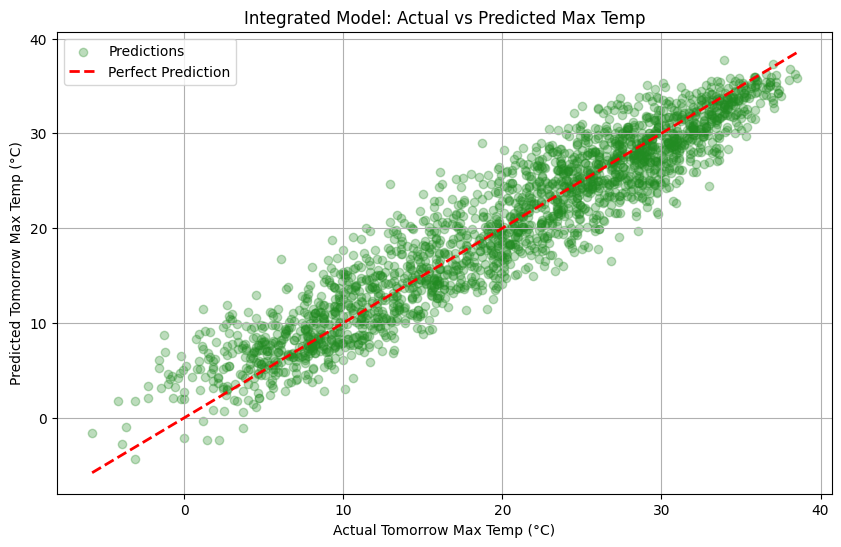


--- 인공지능이 찾아낸 가중치(Coefficients) ---
평균기온(°C)의 영향도: 0.5891
최고기온(°C)의 영향도: 0.3764
평균 상대습도(%)의 영향도: -0.0069
기본 절편(Intercept): 4.2418


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. 데이터 병합
files = ['/workspaces/Daegun26Veritas/data/20503data1.csv', '/workspaces/Daegun26Veritas/data/20503data2.csv', '/workspaces/Daegun26Veritas/data/20503data3.csv']
data_list = [pd.read_csv(f, encoding='cp949') for f in files]
df_full = pd.concat(data_list, ignore_index=True)

# 2. 전처리 및 피처 엔지니어링
df_full['일시'] = pd.to_datetime(df_full['일시'])
df_full = df_full.dropna(subset=['평균기온(°C)', '최고기온(°C)', '평균 상대습도(%)']).copy()

# 내일의 최고기온을 타겟으로 설정
df_full['내일_최고기온'] = df_full['최고기온(°C)'].shift(-1)
df_full = df_full.dropna(subset=['내일_최고기온'])

# 3. 모델 학습
X = df_full[['평균기온(°C)', '최고기온(°C)', '평균 상대습도(%)']]
y = df_full['내일_최고기온']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 4. 결과 출력 및 시각화
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = model.score(X_test, y_test)

print(f"--- 모델 평가 결과 ---")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score (결정계수): {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.3, color='forestgreen', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Integrated Model: Actual vs Predicted Max Temp')
plt.xlabel('Actual Tomorrow Max Temp (°C)')
plt.ylabel('Predicted Tomorrow Max Temp (°C)')
plt.legend()
plt.grid(True)
plt.show()

# 기존 결과 출력 프린트문 바로 아래에 추가해보세요!
print("\n--- 인공지능이 찾아낸 가중치(Coefficients) ---")
for col, coef in zip(X.columns, model.coef_):
    print("{0}의 영향도: {1:.4f}".format(col, coef))
print("기본 절편(Intercept): {0:.4f}".format(model.intercept_))